# Convergence test: reduced chi^2 vs. initial value

Reads `convergence_test_output/convergence_summary.csv` (from `convergence_test.py`) and plots, for each metdep param (alpha_cc, alpha_Ia, g_cc, g_ratio), the reduced chi^2 of the converged fit as a function of the initial value that sweep started from. The top x-axis of each panel relabels the same points with the final optimized value they converged to.

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt

from chemevo import plotstyle

plotstyle.use()

In [2]:
summary_path = os.path.join("convergence_test_output", "convergence_summary.csv")
df = pd.read_csv(summary_path)
df

,swept_param,alpha_cc_init,alpha_Ia_init,g_cc_init,g_ratio_init,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio,reduced_chi2
0,alpha_cc,0.1,0.3,0.4,1.8,0.3,0.5,0.4,1.7,0.011581
1,alpha_cc,0.2,0.3,0.4,1.8,0.4,0.3,0.4,1.7,0.008627
2,alpha_cc,0.3,0.3,0.4,1.8,0.4,0.3,0.4,1.7,0.008627
3,alpha_cc,0.4,0.3,0.4,1.8,0.4,0.3,0.4,1.7,0.008627
4,alpha_cc,0.5,0.3,0.4,1.8,0.4,0.3,0.4,1.7,0.008627
5,alpha_cc,0.6,0.3,0.4,1.8,0.4,0.3,0.4,1.7,0.008627
6,alpha_cc,0.7,0.3,0.4,1.8,0.5,0.2,0.4,1.7,0.008112
7,alpha_cc,0.8,0.3,0.4,1.8,0.6,0.1,0.4,1.7,0.008071
8,alpha_cc,0.9,0.3,0.4,1.8,0.6,0.1,0.4,1.7,0.008071
9,alpha_Ia,0.4,0.1,0.4,1.8,0.6,0.1,0.4,1.7,0.008071


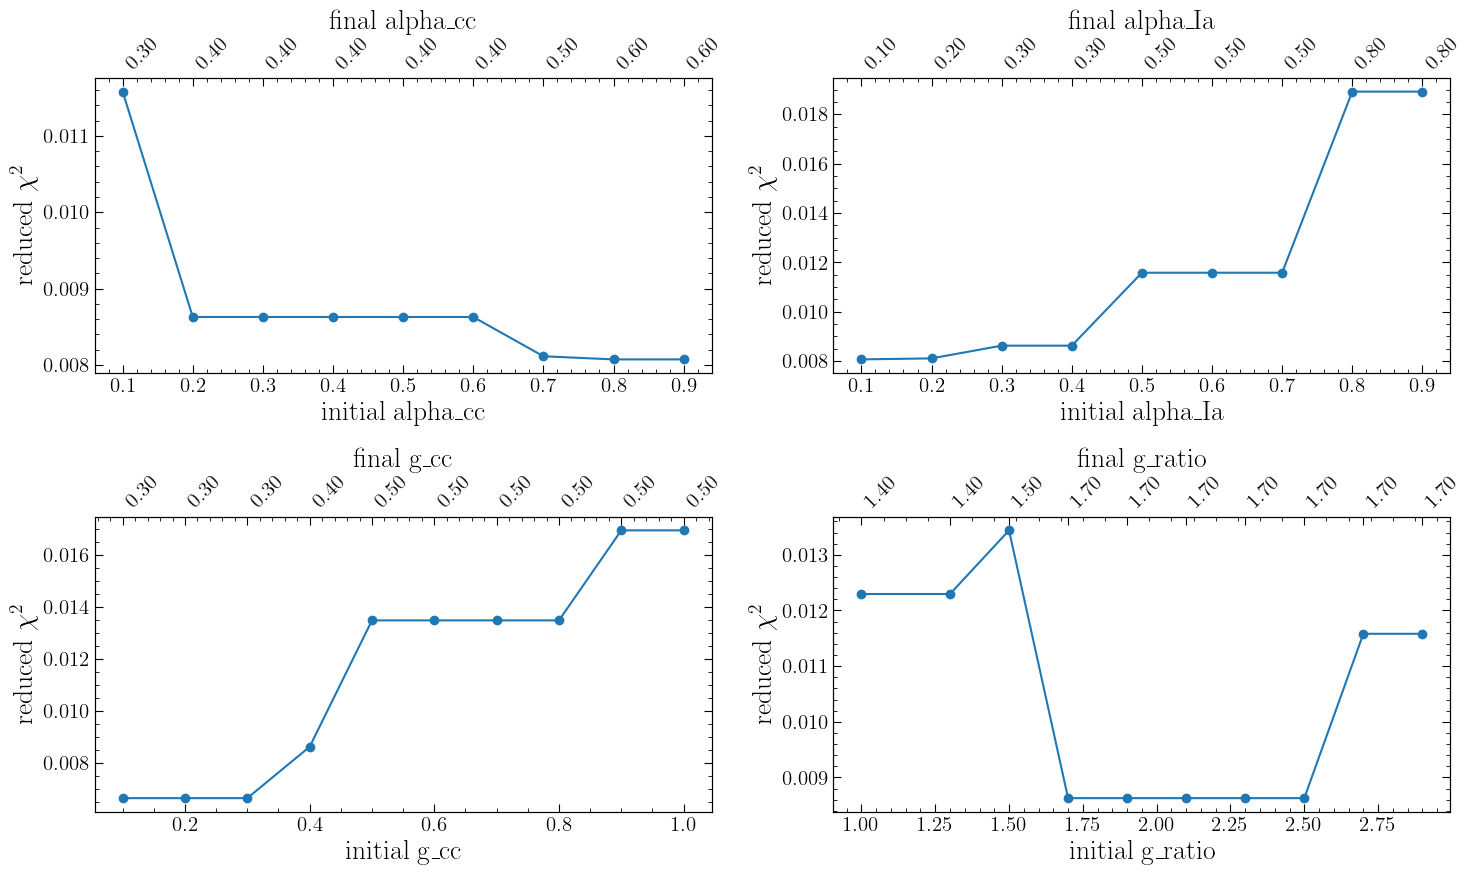

In [3]:
params = ["alpha_cc", "alpha_Ia", "g_cc", "g_ratio"]

# Bottom x-axis positions each point by its initial value (the swept
# variable); the top x-axis relabels those same positions with the final
# optimized value that run converged to.
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for ax, param in zip(axes.flat, params):
    subset = df[df["swept_param"] == param].sort_values(f"{param}_init")
    x_init = subset[f"{param}_init"].values
    x_final = subset[f"best_{param}"].values
    y = subset["reduced_chi2"].values

    ax.plot(x_init, y, marker="o")
    ax.set_xlabel(f"initial {param}")
    ax.set_ylabel(r"reduced $\chi^2$")
    #ax.set_title(param)

    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xticks(x_init)
    ax_top.set_xticklabels([f"{v:.2f}" for v in x_final], rotation=45, ha="left", fontsize=15)
    ax_top.set_xlabel(f"final {param}", fontsize=20)

plt.tight_layout()
plt.show()

In [4]:
df_sorted = df.sort_values(by='reduced_chi2', ascending=True)

In [5]:
df_sorted

,swept_param,alpha_cc_init,alpha_Ia_init,g_cc_init,g_ratio_init,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio,reduced_chi2
18,g_cc,0.4,0.3,0.1,1.8,0.4,0.1,0.3,2.4,0.006651
19,g_cc,0.4,0.3,0.2,1.8,0.4,0.1,0.3,2.4,0.006651
20,g_cc,0.4,0.3,0.3,1.8,0.4,0.1,0.3,2.4,0.006651
7,alpha_cc,0.8,0.3,0.4,1.8,0.6,0.1,0.4,1.7,0.008071
8,alpha_cc,0.9,0.3,0.4,1.8,0.6,0.1,0.4,1.7,0.008071
9,alpha_Ia,0.4,0.1,0.4,1.8,0.6,0.1,0.4,1.7,0.008071
10,alpha_Ia,0.4,0.2,0.4,1.8,0.5,0.2,0.4,1.7,0.008112
6,alpha_cc,0.7,0.3,0.4,1.8,0.5,0.2,0.4,1.7,0.008112
21,g_cc,0.4,0.3,0.4,1.8,0.4,0.3,0.4,1.7,0.008627
31,g_ratio,0.4,0.3,0.4,1.7,0.4,0.3,0.4,1.7,0.008627


In [6]:
summary_path_random = os.path.join("convergence_test_random_output", "convergence_summary_random.csv")
df_random = pd.read_csv(summary_path_random)
df_random_sorted = df_random.sort_values(by="reduced_chi2", ascending=True)
df_random_sorted

,draw,alpha_cc_init,alpha_Ia_init,g_cc_init,g_ratio_init,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio,reduced_chi2
63,63,0.453897,0.247840,0.312996,2.492029,0.353897,0.247840,0.312996,2.392029,0.005399
9,9,0.129922,0.475705,0.304218,2.339628,0.229922,0.375705,0.304218,2.539628,0.005953
38,38,0.140249,0.554036,0.197718,2.344480,0.340249,0.154036,0.297718,2.444480,0.006233
93,93,0.364192,0.314440,0.241850,1.295567,0.464192,0.114440,0.341850,1.995567,0.006348
59,59,0.467382,0.784763,0.116053,1.218288,0.467382,0.084763,0.316053,2.218288,0.006355
...,...,...,...,...,...,...,...,...,...,...
1,1,0.094177,0.975622,0.785026,2.572129,0.294177,0.675622,0.485026,1.272129,0.022420
85,85,0.137408,0.958880,0.820796,2.187364,0.337408,0.658880,0.520796,1.087364,0.023184
33,33,0.581061,0.346870,0.631824,1.045608,0.581061,0.346870,0.631824,0.845608,0.023513
92,92,0.333638,0.898367,0.786279,1.541070,0.433638,0.598367,0.586279,0.941070,0.024998


## [Mn/Fe] vs [Fe/Mg]: the best-converged model from df_sorted

Take the top row of `df_sorted` (lowest reduced chi^2), figure out which run/model that actually is (its swept param + the initial value that identifies its output folder), load the exact model realization that produced that chi^2, and plot it against the data-derived reference lines.

/Users/honeyeah/Codes/chemevo/chemevo/plotting.py:151: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


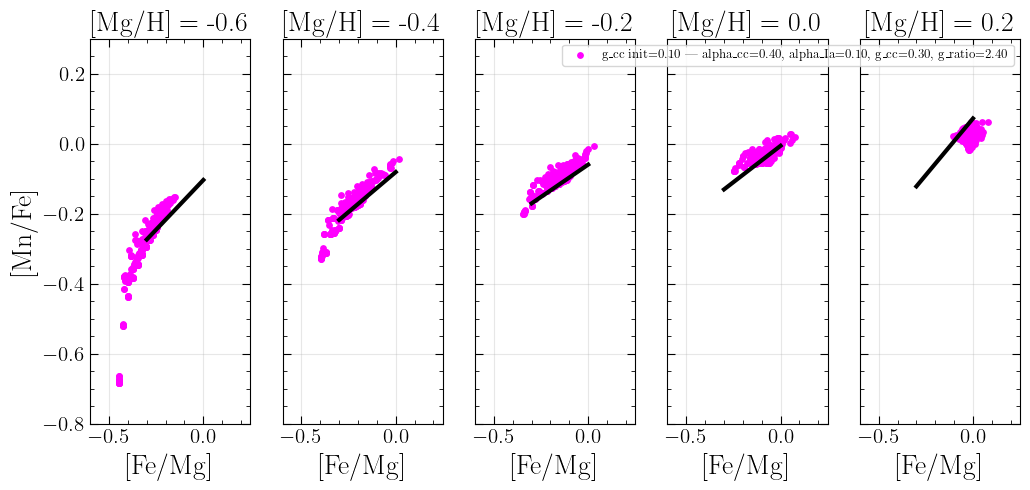

In [7]:
from chemevo.mn_fe_lines import load_mn_fe_lines
from chemevo.plotting import plot_mn_fe_vs_fe_mg

# iterative_1D_loop always fits params in this order each iteration; the
# last one fit in the last iteration is what the final reduced_chi2 (and the
# row's best_* values) came from.
LAST_PARAM = "g_ratio"
N_ITERS = 10


def resolve_best_model_file(row, output_root="convergence_test_output"):
    """
    Given a row of df_sorted, find the exact model-output CSV (one row per
    galaxy endpoint, with fe_mg/mn_fe/mg_h_bin columns) that produced that
    row's reduced_chi2 - i.e. the min-chi2_sum candidate in the last
    param's last-iteration chi_2_results file for that run.
    """
    swept_param = row["swept_param"]
    init_value = row[f"{swept_param}_init"]
    run_dir = os.path.join(output_root, f"{swept_param}_init_{init_value}")

    chi2_path = os.path.join(run_dir, f"chi_2_results_{LAST_PARAM}_iter_{N_ITERS - 1}.csv")
    chi2_df = pd.read_csv(chi2_path)
    best_row = chi2_df.loc[chi2_df["chi_2_sum"].idxmin()]
    return best_row["file"]


best_row = df_sorted.iloc[0]
swept_param = best_row["swept_param"]
init_value = best_row[f"{swept_param}_init"]

model_file = resolve_best_model_file(best_row)
model_df = pd.read_csv(model_file)

label = (
    f"{swept_param} init={init_value:.2f} | "
    f"alpha_cc={best_row['best_alpha_cc']:.2f}, alpha_Ia={best_row['best_alpha_Ia']:.2f}, "
    f"g_cc={best_row['best_g_cc']:.2f}, g_ratio={best_row['best_g_ratio']:.2f}"
)

lines_df = load_mn_fe_lines()
fig, axes = plot_mn_fe_vs_fe_mg({label: model_df}, lines_df, figsize=(12,5), color='magenta')
plt.show()

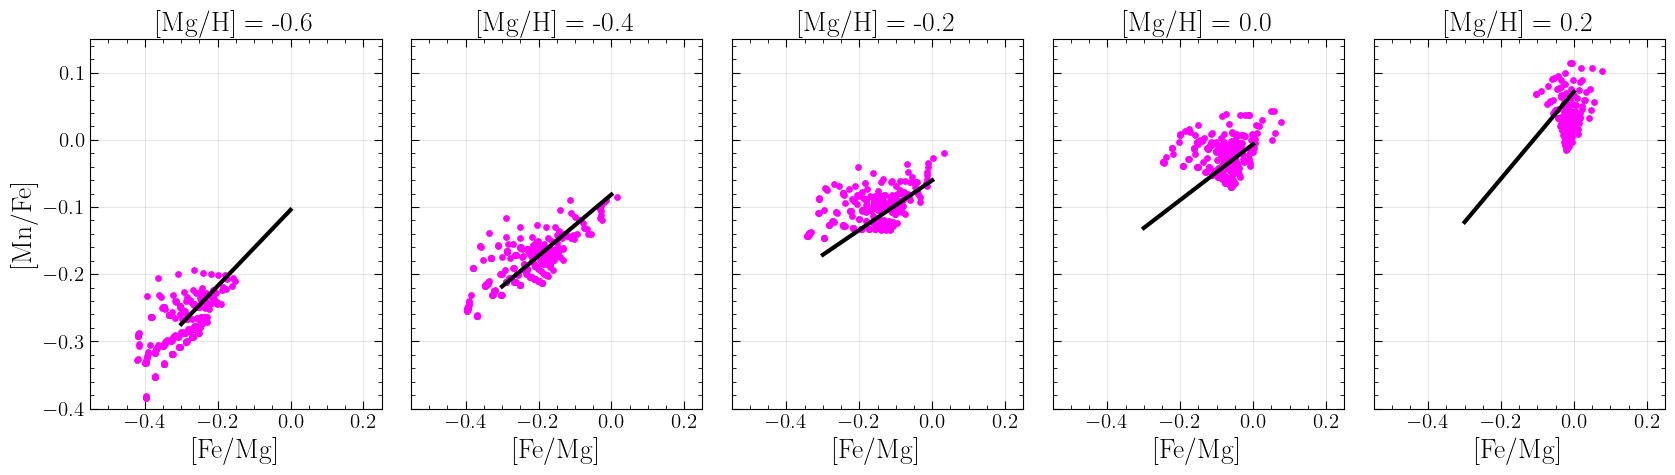

In [8]:
from chemevo.mn_fe_lines import load_mn_fe_lines
from chemevo.plotting import plot_mn_fe_vs_fe_mg

# iterative_1D_loop always fits params in this order each iteration; the
# last one fit in the last iteration is what the final reduced_chi2 (and the
# row's best_* values) came from.
LAST_PARAM = "g_ratio"
N_ITERS = 10


def resolve_best_model_file(row, output_root="convergence_test_output"):
    """
    Given a row of df_sorted, find the exact model-output CSV (one row per
    galaxy endpoint, with fe_mg/mn_fe/mg_h_bin columns) that produced that
    row's reduced_chi2 - i.e. the min-chi2_sum candidate in the last
    param's last-iteration chi_2_results file for that run.
    """
    swept_param = row["swept_param"]
    init_value = row[f"{swept_param}_init"]
    run_dir = os.path.join(output_root, f"{swept_param}_init_{init_value}")

    chi2_path = os.path.join(run_dir, f"chi_2_results_{LAST_PARAM}_iter_{N_ITERS - 1}.csv")
    chi2_df = pd.read_csv(chi2_path)
    best_row = chi2_df.loc[chi2_df["chi_2_sum"].idxmin()]
    return best_row["file"]


best_row = df_sorted.iloc[10]
swept_param = best_row["swept_param"]
init_value = best_row[f"{swept_param}_init"]

model_file = resolve_best_model_file(best_row)
model_df = pd.read_csv(model_file)

label = (
    f"{swept_param} init={init_value:.2f} | "
    f"alpha_cc={best_row['best_alpha_cc']:.2f}, alpha_Ia={best_row['best_alpha_Ia']:.2f}, "
    f"g_cc={best_row['best_g_cc']:.2f}, g_ratio={best_row['best_g_ratio']:.2f}"
)

lines_df = load_mn_fe_lines()
fig, axes = plot_mn_fe_vs_fe_mg({label: model_df}, lines_df, figsize=(17,5), color='magenta', legend_on=0, xlim=(-0.55, 0.25),
                                ylim=(-0.40, 0.15))
plt.show()

In [9]:
df_sorted

,swept_param,alpha_cc_init,alpha_Ia_init,g_cc_init,g_ratio_init,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio,reduced_chi2
18,g_cc,0.4,0.3,0.1,1.8,0.4,0.1,0.3,2.4,0.006651
19,g_cc,0.4,0.3,0.2,1.8,0.4,0.1,0.3,2.4,0.006651
20,g_cc,0.4,0.3,0.3,1.8,0.4,0.1,0.3,2.4,0.006651
7,alpha_cc,0.8,0.3,0.4,1.8,0.6,0.1,0.4,1.7,0.008071
8,alpha_cc,0.9,0.3,0.4,1.8,0.6,0.1,0.4,1.7,0.008071
9,alpha_Ia,0.4,0.1,0.4,1.8,0.6,0.1,0.4,1.7,0.008071
10,alpha_Ia,0.4,0.2,0.4,1.8,0.5,0.2,0.4,1.7,0.008112
6,alpha_cc,0.7,0.3,0.4,1.8,0.5,0.2,0.4,1.7,0.008112
21,g_cc,0.4,0.3,0.4,1.8,0.4,0.3,0.4,1.7,0.008627
31,g_ratio,0.4,0.3,0.4,1.7,0.4,0.3,0.4,1.7,0.008627


In [10]:
df_high_res = pd.read_csv("/Users/honeyeah/Codes/chemevo/examples/metallicity_dependance/iterative_1D_method_higher_res_output/higher_res_summary.csv")
df_high_res

,run_index,alpha_cc_init,alpha_Ia_init,g_cc_init,g_ratio_init,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio,reduced_chi2
0,0,0.4,0.1,0.3,2.4,0.41,0.15,0.30,2.47,0.005536
1,1,0.6,0.1,0.4,1.7,0.54,0.11,0.40,1.63,0.007399
2,2,0.5,0.2,0.4,1.7,0.47,0.18,0.40,1.64,0.007646
3,3,0.4,0.3,0.4,1.7,0.42,0.24,0.39,1.72,0.007685
4,4,0.3,0.5,0.4,1.7,0.38,0.26,0.37,1.85,0.007171


In [11]:
df_sorted

,swept_param,alpha_cc_init,alpha_Ia_init,g_cc_init,g_ratio_init,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio,reduced_chi2
18,g_cc,0.4,0.3,0.1,1.8,0.4,0.1,0.3,2.4,0.006651
19,g_cc,0.4,0.3,0.2,1.8,0.4,0.1,0.3,2.4,0.006651
20,g_cc,0.4,0.3,0.3,1.8,0.4,0.1,0.3,2.4,0.006651
7,alpha_cc,0.8,0.3,0.4,1.8,0.6,0.1,0.4,1.7,0.008071
8,alpha_cc,0.9,0.3,0.4,1.8,0.6,0.1,0.4,1.7,0.008071
9,alpha_Ia,0.4,0.1,0.4,1.8,0.6,0.1,0.4,1.7,0.008071
10,alpha_Ia,0.4,0.2,0.4,1.8,0.5,0.2,0.4,1.7,0.008112
6,alpha_cc,0.7,0.3,0.4,1.8,0.5,0.2,0.4,1.7,0.008112
21,g_cc,0.4,0.3,0.4,1.8,0.4,0.3,0.4,1.7,0.008627
31,g_ratio,0.4,0.3,0.4,1.7,0.4,0.3,0.4,1.7,0.008627


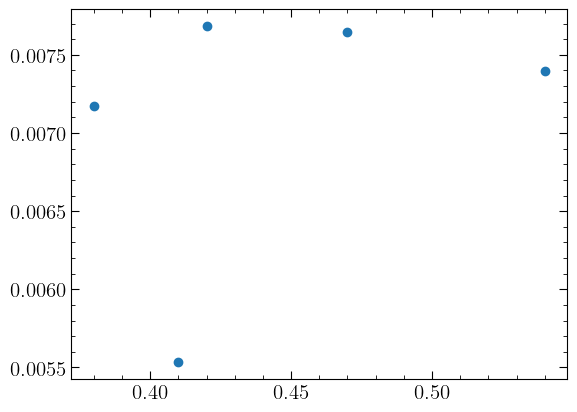

In [12]:
plt.scatter(df_high_res['best_alpha_cc'], df_high_res['reduced_chi2'])

In [16]:
df_sorted_no_dup = df_sorted.drop_duplicates(subset='reduced_chi2', keep='first')
df_sorted_no_dup

,swept_param,alpha_cc_init,alpha_Ia_init,g_cc_init,g_ratio_init,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio,reduced_chi2
18,g_cc,0.4,0.3,0.1,1.8,0.4,0.1,0.3,2.4,0.006651
7,alpha_cc,0.8,0.3,0.4,1.8,0.6,0.1,0.4,1.7,0.008071
10,alpha_Ia,0.4,0.2,0.4,1.8,0.5,0.2,0.4,1.7,0.008112
21,g_cc,0.4,0.3,0.4,1.8,0.4,0.3,0.4,1.7,0.008627
0,alpha_cc,0.1,0.3,0.4,1.8,0.3,0.5,0.4,1.7,0.011581
28,g_ratio,0.4,0.3,0.4,1.0,0.4,0.1,0.4,1.4,0.012296
30,g_ratio,0.4,0.3,0.4,1.5,0.3,0.3,0.4,1.5,0.013440
22,g_cc,0.4,0.3,0.5,1.8,0.5,0.3,0.5,1.2,0.013491
26,g_cc,0.4,0.3,0.9,1.8,0.4,0.5,0.5,1.2,0.016955
17,alpha_Ia,0.4,0.9,0.4,1.8,0.2,0.8,0.4,1.8,0.018915


In [15]:
df_sorted

,swept_param,alpha_cc_init,alpha_Ia_init,g_cc_init,g_ratio_init,best_alpha_cc,best_alpha_Ia,best_g_cc,best_g_ratio,reduced_chi2
18,g_cc,0.4,0.3,0.1,1.8,0.4,0.1,0.3,2.4,0.006651
19,g_cc,0.4,0.3,0.2,1.8,0.4,0.1,0.3,2.4,0.006651
20,g_cc,0.4,0.3,0.3,1.8,0.4,0.1,0.3,2.4,0.006651
7,alpha_cc,0.8,0.3,0.4,1.8,0.6,0.1,0.4,1.7,0.008071
8,alpha_cc,0.9,0.3,0.4,1.8,0.6,0.1,0.4,1.7,0.008071
9,alpha_Ia,0.4,0.1,0.4,1.8,0.6,0.1,0.4,1.7,0.008071
10,alpha_Ia,0.4,0.2,0.4,1.8,0.5,0.2,0.4,1.7,0.008112
6,alpha_cc,0.7,0.3,0.4,1.8,0.5,0.2,0.4,1.7,0.008112
21,g_cc,0.4,0.3,0.4,1.8,0.4,0.3,0.4,1.7,0.008627
31,g_ratio,0.4,0.3,0.4,1.7,0.4,0.3,0.4,1.7,0.008627
